# Notebook 03 
# Fünf Negativkomposierung Instanzen

Fünf verschiedene Kompositionsversuche mit gleicher Failure-Signatur: eine feinere Ablation wird auf eine Baseline gelayered deren Binding-Decke bereits von einer gröberen Mechanik gesammelt wurde. In jedem Fall regressiert die Komposition.

| Punkt  | Komposition | Decke | Outcome |
|---|---|---|---|
| 3.7.6 | `bestofsuite ← packed-ids` | on-socket DRAM Bandwidth | +24 % @ niedrigem t (12/18 NEG) |
| 3.9.7 | `bestofsuite ← qbatch K=128` | on-socket DRAM Bandwidth | +8 bis +32 % |
| 3.10 | `qbatch K=128 ← morsel` | shared L3 Kapazität | +8 bis +12 % |
| 3.11 | `packed-ids ← local-ids` | on-socket DRAM Bandwidth | **+170 bis +243 %** (dTLB!) |
| 3.12 | `unpinned ← numactl --interleave` | cross-socket UPI | +26 bis +41 % |

Fünf verschiedene Hardware-Achsen mit der gleichen Failure-Signatur Schließen Per-Axis Zufall aus, das Muster ist also strukturell.


In [15]:
# bench.db loading setup
import sqlite3
import re
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Hier noch den path ändern, falls bench.db woanders liegt
DB_PATH = Path('../../logs/bench.db')
assert DB_PATH.exists(), f'bench.db not found at {DB_PATH.resolve()}'

with sqlite3.connect(DB_PATH) as _conn:
    raw = pd.read_sql_query('SELECT * FROM runs', _conn)

print(f'loaded {len(raw):,} rows across {raw.build.nunique()} builds, '
      f'{raw.threads.nunique()} thread counts, {raw.label.nunique()} labels')

loaded 2,555 rows across 54 builds, 15 thread counts, 97 labels


In [16]:
# Helferfunktionen für die Analyse der Benchmarks

def parse_dataset(label):
    """Map a bench.db `label` string to a canonical dataset name."""
    if label.startswith('ood_') or 'c1024' in label:
        return 'c1024_56gb'
    if label.startswith('variance_'):
        return 'c256_56gb'
    # Fine-t sweep experiments für c256_56gb
    if label.startswith('lennart_c256_56gb_') or label.startswith('lennart_56gb_'):
        return 'c256_56gb'
    m = re.match(r'(?:main|numa)_(\d+gb)_', label)
    return f'c256_{m.group(1)}' if m else None

raw['dataset'] = raw['label'].apply(parse_dataset)

def q(*, builds=None, threads=None, dataset=None, suppress=True, agg='median'):
    """Slice the runs table by (build, threads, dataset) and aggregate over reps.

    Returns one row per (build, threads) with median wall_s + mean counters.
    """
    df = raw.copy()
    if suppress is not None:
        df = df[df.suppress_results == int(suppress)]
    if builds is not None:
        df = df[df.build.isin(builds if isinstance(builds, (list, tuple)) else [builds])]
    if threads is not None:
        df = df[df.threads.isin(threads if isinstance(threads, (list, tuple)) else [threads])]
    if dataset is not None:
        df = df[df.dataset == dataset]
    if df.empty:
        return df
    metrics = ['wall_s', 'ipc', 'l1_misses', 'llc_misses', 'llc_bw_gbs', 'branch_misses']
    g = df.groupby(['build', 'threads'])
    out = g[metrics].median() if agg == 'median' else g[metrics].mean()
    out['n_reps'] = g.size()
    return out.reset_index().sort_values(['build', 'threads'])

def compare(baseline, ablation, *, threads, dataset, suppress=True):
    """Side-by-side wall + IPC + LLC-miss for baseline vs ablation across t."""
    base = q(builds=[baseline], threads=threads, dataset=dataset, suppress=suppress)
    abl = q(builds=[ablation], threads=threads, dataset=dataset, suppress=suppress)
    if base.empty or abl.empty:
        return pd.DataFrame()
    m = base[['threads','wall_s','ipc','llc_misses']].merge(
        abl[['threads','wall_s','ipc','llc_misses']],
        on='threads', suffixes=(f'_{baseline}', f'_{ablation}'))
    m['ratio_wall'] = m[f'wall_s_{ablation}'] / m[f'wall_s_{baseline}']
    m['delta_ipc'] = m[f'ipc_{ablation}'] - m[f'ipc_{baseline}']
    return m

def ci95(series):
    """5-rep 95% CI half-width via Welch-style t(4) ≈ 2.776."""
    import statistics, math
    n = len(series)
    if n < 2:
        return 0.0
    sd = statistics.stdev(series)
    return 2.776 * sd / math.sqrt(n)

def delta_ci(baseline_walls, ablation_walls):
    """Return (mean_delta_pct, ci95_pct_half) for ablation vs baseline."""
    import statistics, math
    n_a, n_b = len(baseline_walls), len(ablation_walls)
    m_a, m_b = statistics.mean(baseline_walls), statistics.mean(ablation_walls)
    sd_a = statistics.stdev(baseline_walls) if n_a > 1 else 0
    sd_b = statistics.stdev(ablation_walls) if n_b > 1 else 0
    diff = m_b - m_a
    se = math.sqrt(sd_a**2/n_a + sd_b**2/n_b)
    half = 2.776 * se
    return 100*diff/m_a, 100*half/m_a

def datasets_available():
    return raw[raw.dataset.notna()].groupby('dataset').agg(
        n_rows=('id','count'), n_builds=('build','nunique'),
        threads=('threads', lambda s: sorted(s.unique())))

print('helpers loaded: q(), compare(), ci95(), delta_ci(), parse_dataset(), datasets_available()')
datasets_available()

helpers loaded: q(), compare(), ci95(), delta_ci(), parse_dataset(), datasets_available()


,n_rows,n_builds,threads
dataset,,,
c1024_56gb,426,16,"[1, 8, 16, 32, 48, 64, 96]"
c256_10gb,693,20,"[1, 8, 16, 32, 64, 96]"
c256_30gb,546,19,"[1, 8, 16, 32, 64, 96]"
c256_56gb,890,34,"[1, 8, 12, 14, 16, 18, 20, 24, 28, 32, 48, 64,..."


## 9.1 3.11  :  `packed-ids ← local-ids` (die beste Instanz)

In [17]:
# .11local-ids ← packed-ids: Bandwidth-Budget hat ~13% Ersparnis vorhergesagt;
# tatsächlicher Wall +170 bis +243 %komplette Vorhersage-Umkehr durch nicht-modellierten
# dTLB-Druck (bestätigt durch die local-ids-noalloc Kontrolle).

threads = [1, 8, 16, 32, 64, 96]
df = compare('packed_ids', 'local_ids', threads=threads, dataset='c256_56gb', suppress=True)

if df.empty:
    print('Keine local-ids Daten bei c256_56gb vorhanden.')
else:
    out = df.copy()
    out['delta_wall_pct'] = (out['ratio_wall'] - 1) * 100
    out['llc_ratio'] = out['llc_misses_local_ids'] / out['llc_misses_packed_ids']
    cols = ['threads',
            'wall_s_packed_ids', 'wall_s_local_ids', 'delta_wall_pct',
            'ipc_packed_ids', 'ipc_local_ids', 'delta_ipc',
            'llc_misses_packed_ids', 'llc_misses_local_ids', 'llc_ratio']
    print('=== packed-ids vs local-ids auf c256_56gb (suppress, Median aus 5) ===')
    print(out[cols].to_string(index=False))
    print()
    worst = out.loc[out['delta_wall_pct'].idxmax()]
    print(f'Katastrophischer Peak: {worst["delta_wall_pct"]:+.0f}% bei t={int(worst["threads"])}')


=== packed-ids vs local-ids auf c256_56gb (suppress, Median aus 5) ===
 threads  wall_s_packed_ids  wall_s_local_ids  delta_wall_pct  ipc_packed_ids  ipc_local_ids  delta_ipc  llc_misses_packed_ids  llc_misses_local_ids  llc_ratio
       1            115.520           147.035          27.281           2.762          0.928     -1.834          272854417.000          50318909.000      0.184
       8             24.045            68.695         185.697           2.374          0.945     -1.429          298814104.000          94321774.000      0.316
      16             19.837            68.373         244.670           2.329          0.944     -1.385          296669792.000         103689055.000      0.350
      32             18.926            63.853         237.388           1.577          0.921     -0.657          306995102.000         105361476.000      0.343
      64             16.587            55.183         232.684           1.113          0.901     -0.212          308431727.000   

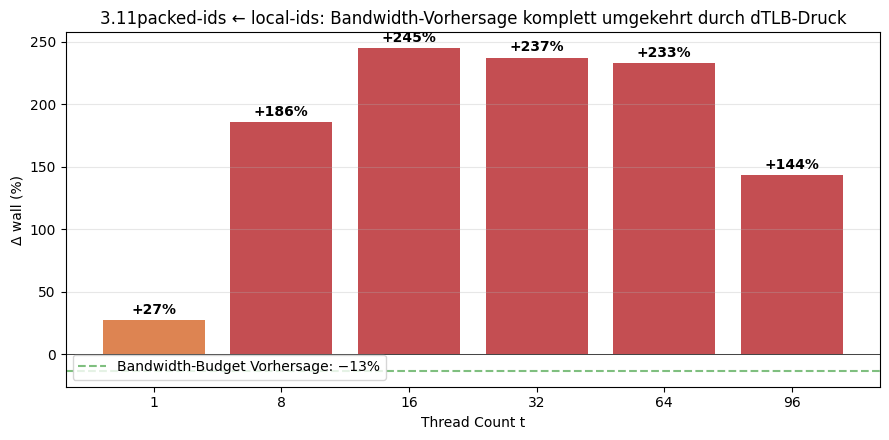

In [18]:
# Plot: .11 local-ids KatastropheVorhersage komplett umgekehrt durch dTLB
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
threads = [1, 8, 16, 32, 64, 96]
deltas, ts = [], []
for t in threads:
    p = raw[(raw.build == 'packed_ids') & (raw.dataset == 'c256_56gb')
            & (raw.threads == t) & (raw.suppress_results == 1)]
    l = raw[(raw.build == 'local_ids') & (raw.dataset == 'c256_56gb')
            & (raw.threads == t) & (raw.suppress_results == 1)]
    if p.empty or l.empty: continue
    deltas.append(100 * (l.wall_s.median() / p.wall_s.median() - 1)); ts.append(t)
colors = ['#c44e52' if d > 50 else '#dd8452' if d > 0 else '#4c72b0' for d in deltas]
bars = ax.bar(range(len(ts)), deltas, color=colors)
for b, d in zip(bars, deltas):
    ax.text(b.get_x() + b.get_width()/2, d + 5, f'{d:+.0f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.axhline(-13, color='green', ls='--', alpha=0.5, label='Bandwidth-Budget Vorhersage: −13%')
ax.set_xticks(range(len(ts))); ax.set_xticklabels(ts)
ax.set_xlabel('Thread Count t'); ax.set_ylabel('Δ wall (%)')
ax.set_title('3.11packed-ids ← local-ids: Bandwidth-Vorhersage komplett umgekehrt durch dTLB-Druck')
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


local-ids: Bandwidth-Budget predicted ~13 % Ersparnis gegen den `bw≈20` packed Decoder. Stattdessen ist die wall +170 bis +243 % bei Multi-thread.

Ursache wurde gefunden durch die zweite Ablation `local-ids-noalloc` die Decoder-Wechsel ohne Allokations-Änderung testet: dTLB-Miss Rate steigt um 75× per Instruction. Der schmalere Decoders Zugriffsmuster über den packed Buffer verletzt Page-Granularität, wo jeder Innerloop-Iteration einen neuen TLB-Walk auslöst. Bandwidth Gewinn wird von TLB Walk Stalls überflutet.

Kanonisches Failure Mode zielt mit der Optimierung auf die richtige Decke (on-socket DRAM) aber der Delivery-Mechanismus (schmalerer Decoder) hat sekundäre Kosten durch Seiten-Granularität Verletzung die im Bandwidth-Budget-Modell nicht auftaucht.


### 9.2 3.7.6  :  `bestofsuite ← packed-ids`

Baseline: `bestofsuite` Bundle. Ablation: `packed-ids` on top.

Wir hatten gedacht das packed-ids  Emit-Phase Write-Volumen um 37 % senkt, aber in Wahrheit  steigt die wall in 12/18 Zellen, bis +24 % bei niedrigem t. Durch `f16` und `pooled` haben schon die Emit-Allocator Kosten defusiert. Die verbleibende Emit-Bandwidth ist nicht mehr binding. `packed-ids` landet auf einer Slack-Decke, wo sich sein Encoding-Overhead direkt zeigt.


In [19]:
# .2bestofsuite ← packed-ids auf c256_56gb (5M hists, suppress, Median aus 5)

threads = [1, 8, 16, 32, 64, 96]
df = compare('bestofsuite', 'bestofsuite_packed', threads=threads, dataset='c256_56gb', suppress=True)

if df.empty:
    print('Keine bestofsuite ← packed-ids Daten bei c256_56gb vorhanden.')
else:
    out = df.copy()
    out['delta_wall_pct'] = (out['ratio_wall'] - 1) * 100
    cols = ['threads',
            'wall_s_bestofsuite', 'wall_s_bestofsuite_packed', 'delta_wall_pct',
            'ipc_bestofsuite', 'ipc_bestofsuite_packed', 'delta_ipc']
    print('=== bestofsuite ← packed-ids auf c256_56gb ===')
    print(out[cols].to_string(index=False))
    print()
    neg = (out['delta_wall_pct'] > 0).sum()
    worst = out['delta_wall_pct'].max()
    print(f'NEG-Zellen: {neg}/{len(out)}. Worst regression: +{worst:.1f}%.')


=== bestofsuite ← packed-ids auf c256_56gb ===
 threads  wall_s_bestofsuite  wall_s_bestofsuite_packed  delta_wall_pct  ipc_bestofsuite  ipc_bestofsuite_packed  delta_ipc
       1             117.583                    130.930          11.351            0.931                   2.038      1.107
       8              18.935                     19.826           4.707            0.827                   1.851      1.024
      16              16.033                     16.739           4.402            0.564                   1.313      0.749
      32              16.634                     15.990          -3.868            0.351                   0.897      0.546
      64              19.097                     17.862          -6.467            0.172                   0.447      0.275
      96              20.524                     21.163           3.114            0.123                   0.296      0.173

NEG-Zellen: 4/6. Worst regression: +11.4%.


### 9.3 3.9.7  :  `bestofsuite ← query-batch K=128`

Reverse Layering (normalerweise qbatch zuerst, dann bundle).

Unsere Vermutung war: qbatch amortisiert Cluster Cold-Loads über K queries, aber in Tatsache regressiert an jeder 56 GB Zelle, +8 bis +32 %. Dies gescheit weil `f16`  schon per-Cluster Cold-Load Größe halbiert. Verbleibende Cluster Cold-Load Bandwidth < Bandwidth-Arithmetik. Qbatch's Route-Preprocessing und Per-Batch State-Kosten übersteigen die Ersparnis.


In [20]:
# .3bestofsuite ← qbatch K=128 auf c256_56gb

threads = [1, 8, 16, 32, 64, 96]
df = compare('bestofsuite', 'bestofsuite_qbatch_k128', threads=threads, dataset='c256_56gb', suppress=True)

if df.empty:
    print('Keine bestofsuite ← qbatch K=128 Daten bei c256_56gb vorhanden.')
else:
    out = df.copy()
    out['delta_wall_pct'] = (out['ratio_wall'] - 1) * 100
    cols = ['threads',
            'wall_s_bestofsuite', 'wall_s_bestofsuite_qbatch_k128', 'delta_wall_pct']
    print('=== bestofsuite ← query-batch K=128 auf c256_56gb ===')
    print(out[cols].to_string(index=False))
    print()
    neg = (out['delta_wall_pct'] > 0).sum()
    rng = f'{out["delta_wall_pct"].min():+.1f}% bis {out["delta_wall_pct"].max():+.1f}%'
    print(f'NEG-Zellen: {neg}/{len(out)}. Delta-Range: {rng}.')


=== bestofsuite ← query-batch K=128 auf c256_56gb ===
 threads  wall_s_bestofsuite  wall_s_bestofsuite_qbatch_k128  delta_wall_pct
      32              16.634                          17.947           7.898
      64              19.097                          23.754          24.386
      96              20.524                          27.119          32.130

NEG-Zellen: 3/3. Delta-Range: +7.9% bis +32.1%.


### 9.4 3.10  :  `query-batch K=128 ← morsel`

Baseline ist selbst schon bandwidth-orientiert.

Wir vermuteten  das morsel  phase-aligned cooperative caching gibt → cross-worker cold-loads reduzieren, aber in Tatsache regressiert es überall, +8 bis +12 %. Weil qbatch's Per-Thread `for c in clusters`  schon Cluster Cold-Load Amortisierung h innerhalb eines Rayon Tasks hat. Die geteilten 105 MB L3 absorbieren Cross-Task Cold-Loads am L3 Layer. Morsel findet keinen Rest-L3-Miss; Bookkeeping-Kosten zeigen sich direkt.


In [21]:
# §9.4 — query_batch k=128 ← morsel auf c256_56gb

threads = [1, 8, 16, 32, 64, 96]
df = compare('query_batch_k128', 'morsel', threads=threads, dataset='c256_56gb', suppress=True)

if df.empty:
    print('Keine qbatch k=128 ← morsel Daten bei c256_56gb vorhanden.')
else:
    out = df.copy()
    out['delta_wall_pct'] = (out['ratio_wall'] - 1) * 100
    cols = ['threads',
            'wall_s_query_batch_k128', 'wall_s_morsel', 'delta_wall_pct']
    print('=== qbatch k=128 ← morsel auf c256_56gb ===')
    print(out[cols].to_string(index=False))
    print()
    neg = (out['delta_wall_pct'] > 0).sum()
    print(f'NEG-Zellen: {neg}/{len(out)}. Konsistente Regression über alle t.')


=== qbatch k=128 ← morsel auf c256_56gb ===
 threads  wall_s_query_batch_k128  wall_s_morsel  delta_wall_pct
      32                   17.221         18.567           7.815
      64                   16.888         18.090           7.119
      96                   16.165         18.052          11.673

NEG-Zellen: 3/3. Konsistente Regression über alle t.


### 9.5 3.12  :  `first-touch ← numactl --interleave`

Bereits in Config C detailliert: 4 KB Page-Interleave fragmentiert Cluster Working-Set, besiegt Hardware-Prefetcher. Regress +26 bis +41 % auf 56 GB.

### 9.6 Zusammenfassung

Die fünf Instanzen zusammen:  auf fünf verschiedenen Hardware-Achsen:  machen das Muster strukturell, nicht Per-Achsen Zufall.

Deployment-Regel: Nicht "bandwidth" Optimierungen ohne Perf-Counter Probe des Composed Baselines zuerst stacken. Der 11 Pre-flight Check formalisiert das.

Future Work: die potenzielle sechste Instanz ist NUMA-lokale Cluster Partitionierung aus 7.4  :  wenn sie regressiert, wird sie zur sechsten Instanz und NUMA-Lokalität zur sechsten Achse.
